# New Section

# 1.Setup & Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

folder_path = "/content/drive/MyDrive/Hasil Keseluruhan Data"

# cek semua file yang ada di folder
print("Isi folder:")
print(os.listdir(folder_path))

# load dataset hasil filtering
df = pd.read_csv(f"{folder_path}/dataset_hantavirus_mei_juni_2026.csv")
print(f"\nJumlah data: {len(df)}")
df.head()

Mounted at /content/drive
Isi folder:
['dataset_tiktok_gabungan_final.csv', 'kamus_normalisasi.csv', 'inset_positif.csv', 'inset_negatif.csv', 'dataset_final_for_split.csv', 'hasil_prediksi.pkl', 'prediksi_linearsvc.pkl', 'prediksi_naivebayes.pkl', 'hasil_evaluasi.pkl', 'dataset_hantavirus_mei_juni_2026.csv', 'dataset_hantavirus_labeled.gsheet', 'model_linearsvc.pkl', 'model_naivebayes.pkl', 'distribusi_label_sentimen.csv', 'tfidf_vectorizer.pkl', 'tfidf_matrix.npz', 'hasil_pembobotan_tfidf_bab4.csv', 'hasil_pembobotan_tfidf_bab4.gsheet', 'train_test_split.pkl', 'tabel_train_test_split.csv', 'tabel_distribusi_train_test.csv', 'confusion_matrix_linearsvc.csv', 'confusion_matrix_naivebayes.csv', 'confusion_matrix_linearsvc.png', 'confusion_matrix_naivebayes.png', 'perbandingan_performa_model.csv', 'perbandingan_akurasi_model.png', 'dataset_cleaning.gsheet', 'visualisasi_distribusi_sentimen.png', 'dataset_cleaning.csv', 'dataset_hantavirus_tokenizing.csv', 'dataset_hantavirus_normalizatio

,tanggal,nama_akun,teks
0,2026-05-05 04:18:23+00:00,aajuianbakk9,bisnis apa lagi ini
1,2026-05-05 03:11:33+00:00,firmandafahmis,libur berapa tahun lagi ini?
2,2026-05-05 04:34:11+00:00,fashionstudio_ai,project siapa lagi ini ??
3,2026-05-05 02:48:28+00:00,milavryn,Gua gak mau kek Covid lagi tolong 😭
4,2026-05-05 03:39:34+00:00,dempo20,klian percaya???


In [2]:
output_path = f"{folder_path}/dataset_hantavirus_preprocessed.csv"
df.to_csv(output_path, index=False)
print(f"Dataset hasil preprocessing disimpan di: {output_path}")

Dataset hasil preprocessing disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_preprocessed.csv


In [3]:
import os
folder_path = "/content/drive/MyDrive/Hasil Keseluruhan Data"
print(os.listdir(folder_path))

['dataset_tiktok_gabungan_final.csv', 'kamus_normalisasi.csv', 'inset_positif.csv', 'inset_negatif.csv', 'dataset_final_for_split.csv', 'hasil_prediksi.pkl', 'prediksi_linearsvc.pkl', 'prediksi_naivebayes.pkl', 'hasil_evaluasi.pkl', 'dataset_hantavirus_mei_juni_2026.csv', 'dataset_hantavirus_labeled.gsheet', 'model_linearsvc.pkl', 'model_naivebayes.pkl', 'distribusi_label_sentimen.csv', 'tfidf_vectorizer.pkl', 'tfidf_matrix.npz', 'hasil_pembobotan_tfidf_bab4.csv', 'hasil_pembobotan_tfidf_bab4.gsheet', 'train_test_split.pkl', 'tabel_train_test_split.csv', 'tabel_distribusi_train_test.csv', 'confusion_matrix_linearsvc.csv', 'confusion_matrix_naivebayes.csv', 'confusion_matrix_linearsvc.png', 'confusion_matrix_naivebayes.png', 'perbandingan_performa_model.csv', 'perbandingan_akurasi_model.png', 'dataset_cleaning.gsheet', 'visualisasi_distribusi_sentimen.png', 'dataset_cleaning.csv', 'dataset_hantavirus_tokenizing.csv', 'dataset_hantavirus_normalization.csv', 'dataset_hantavirus_casefoldin

In [4]:
print("Hasil Keseluruhan Data" in os.listdir("/content/drive/MyDrive"))

True


# 2.Text Preprocessing

In [5]:
!pip install Sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 11.9 MB/s eta 0:00:00


## 2.1 Cleaning

In [6]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_mei_juni_2026.csv"
)

print(f"Jumlah data awal: {len(df)}")

Jumlah data awal: 5199


In [7]:
import re
import string

def remove_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "\U00002600-\U000026FF"
        "\U0001FA70-\U0001FAFF"
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r"", text)

def cleaning(text):
    if not isinstance(text, str):
        return ""

    text = remove_emoji(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [8]:
df["text_clean"] = df["teks"].apply(cleaning)

# Menghapus data yang kosong setelah cleaning
df = df[
    df["text_clean"].notna() &
    (df["text_clean"].str.strip() != "")
].copy()

print(f"Jumlah data setelah cleaning: {len(df)}")

Jumlah data setelah cleaning: 4891


In [9]:
df.to_csv(
    f"{folder_path}/dataset_cleaning.csv",
    index=False
)

print("Hasil cleaning berhasil disimpan di Google Drive.")

Hasil cleaning berhasil disimpan di Google Drive.


## 2.2 Case Folding

In [10]:
def case_folding(text):
    return text.lower()

df["text_casefolding"] = df["text_clean"].apply(case_folding)

df[["text_clean", "text_casefolding"]].head(10)

,text_clean,text_casefolding
0,bisnis apa lagi ini,bisnis apa lagi ini
1,libur berapa tahun lagi ini,libur berapa tahun lagi ini
2,project siapa lagi ini,project siapa lagi ini
3,Gua gak mau kek Covid lagi tolong,gua gak mau kek covid lagi tolong
4,klian percaya,klian percaya
5,Singkat saja Kapan mulai libur Berapa tahun,singkat saja kapan mulai libur berapa tahun
6,jangan percaya yg namanya WHO,jangan percaya yg namanya who
7,To the point aja berapa tahun,to the point aja berapa tahun
8,udahla anj cape bgt cape,udahla anj cape bgt cape
9,saham apa yg bakal naik nih,saham apa yg bakal naik nih


In [11]:
output_path = f"{folder_path}/dataset_hantavirus_casefolding.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil case folding disimpan di: {output_path}")

Dataset hasil case folding disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_casefolding.csv


## 2.3 Normalization

In [12]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_casefolding.csv"
)

df["text_casefolding"] = df["text_casefolding"].fillna("")

In [13]:
kamus_df = pd.read_csv(
    f"{folder_path}/kamus_normalisasi.csv"
)

kamus_normalisasi = dict(
    zip(kamus_df["slang"], kamus_df["formal"])
)

print(f"Jumlah pasangan kata di kamus: {len(kamus_normalisasi)}")

Jumlah pasangan kata di kamus: 4331


In [14]:
def normalisasi(text):
    words = text.split()
    words = [kamus_normalisasi.get(word, word) for word in words]
    return " ".join(words)

In [15]:
df["text_normalization"] = df["text_casefolding"].apply(normalisasi)

df[["text_casefolding", "text_normalization"]].head(10)

,text_casefolding,text_normalization
0,bisnis apa lagi ini,bisnis apa lagi ini
1,libur berapa tahun lagi ini,libur berapa tahun lagi ini
2,project siapa lagi ini,project siapa lagi ini
3,gua gak mau kek covid lagi tolong,gua enggak mau kayak covid lagi tolong
4,klian percaya,kalian percaya
5,singkat saja kapan mulai libur berapa tahun,singkat saja kapan mulai libur berapa tahun
6,jangan percaya yg namanya who,jangan percaya yang namanya who
7,to the point aja berapa tahun,tapi the point saja berapa tahun
8,udahla anj cape bgt cape,udahla anjing capek banget capek
9,saham apa yg bakal naik nih,saham apa yang bakal naik nih


In [16]:
output_path = f"{folder_path}/dataset_hantavirus_normalization.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil normalisasi disimpan di: {output_path}")

Dataset hasil normalisasi disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_normalization.csv


## 2.4 Tokenizing

In [17]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_normalization.csv"
)

df["text_normalization"] = df["text_normalization"].fillna("")

In [18]:
df["text_token"] = df["text_normalization"].apply(lambda x: x.split())

df[["text_normalization", "text_token"]].head(10)

,text_normalization,text_token
0,bisnis apa lagi ini,"[bisnis, apa, lagi, ini]"
1,libur berapa tahun lagi ini,"[libur, berapa, tahun, lagi, ini]"
2,project siapa lagi ini,"[project, siapa, lagi, ini]"
3,gua enggak mau kayak covid lagi tolong,"[gua, enggak, mau, kayak, covid, lagi, tolong]"
4,kalian percaya,"[kalian, percaya]"
5,singkat saja kapan mulai libur berapa tahun,"[singkat, saja, kapan, mulai, libur, berapa, t..."
6,jangan percaya yang namanya who,"[jangan, percaya, yang, namanya, who]"
7,tapi the point saja berapa tahun,"[tapi, the, point, saja, berapa, tahun]"
8,udahla anjing capek banget capek,"[udahla, anjing, capek, banget, capek]"
9,saham apa yang bakal naik nih,"[saham, apa, yang, bakal, naik, nih]"


In [19]:
output_path = f"{folder_path}/dataset_hantavirus_tokenizing.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil tokenizing disimpan di: {output_path}")

Dataset hasil tokenizing disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_tokenizing.csv


## 2.5 Stopword Removal

In [20]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_tokenizing.csv"
)

In [21]:
import ast

df["text_token"] = df["text_token"].apply(ast.literal_eval)

In [22]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

In [23]:
def stopword_removal(tokens):
    return [word for word in tokens if word not in stopwords]

df["text_stopword"] = df["text_token"].apply(stopword_removal)

df[["text_token", "text_stopword"]].head(10)

,text_token,text_stopword
0,"[bisnis, apa, lagi, ini]","[bisnis, apa]"
1,"[libur, berapa, tahun, lagi, ini]","[libur, berapa, tahun]"
2,"[project, siapa, lagi, ini]","[project, siapa]"
3,"[gua, enggak, mau, kayak, covid, lagi, tolong]","[gua, enggak, mau, kayak, covid]"
4,"[kalian, percaya]","[kalian, percaya]"
5,"[singkat, saja, kapan, mulai, libur, berapa, t...","[singkat, kapan, mulai, libur, berapa, tahun]"
6,"[jangan, percaya, yang, namanya, who]","[jangan, percaya, namanya, who]"
7,"[tapi, the, point, saja, berapa, tahun]","[the, point, berapa, tahun]"
8,"[udahla, anjing, capek, banget, capek]","[udahla, anjing, capek, banget, capek]"
9,"[saham, apa, yang, bakal, naik, nih]","[saham, apa, bakal, naik, nih]"


In [24]:
output_path = f"{folder_path}/dataset_hantavirus_stopword.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil stopword removal disimpan di: {output_path}")

Dataset hasil stopword removal disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_stopword.csv


## 2.6 Stemming

In [25]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stopword.csv"
)

import ast

df["text_stopword"] = df["text_stopword"].apply(ast.literal_eval)

In [26]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [27]:
def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df["text_stemming"] = df["text_stopword"].apply(stemming)

df[["text_stopword", "text_stemming"]].head(10)

,text_stopword,text_stemming
0,"[bisnis, apa]","[bisnis, apa]"
1,"[libur, berapa, tahun]","[libur, berapa, tahun]"
2,"[project, siapa]","[project, siapa]"
3,"[gua, enggak, mau, kayak, covid]","[gua, enggak, mau, kayak, covid]"
4,"[kalian, percaya]","[kalian, percaya]"
5,"[singkat, kapan, mulai, libur, berapa, tahun]","[singkat, kapan, mulai, libur, berapa, tahun]"
6,"[jangan, percaya, namanya, who]","[jangan, percaya, nama, who]"
7,"[the, point, berapa, tahun]","[the, point, berapa, tahun]"
8,"[udahla, anjing, capek, banget, capek]","[udahla, anjing, capek, banget, capek]"
9,"[saham, apa, bakal, naik, nih]","[saham, apa, bakal, naik, nih]"


In [28]:
output_path = f"{folder_path}/dataset_hantavirus_stemming.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil stemming disimpan di: {output_path}")

Dataset hasil stemming disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_stemming.csv


#3.Pelabelan Sentimen (Rule-Based InSet Lexicon)

In [29]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stemming.csv"
)

import ast

df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

In [30]:
inset_positif = pd.read_csv(
    f"{folder_path}/inset_positif.csv"
)

inset_negatif = pd.read_csv(
    f"{folder_path}/inset_negatif.csv"
)

In [31]:
print(inset_positif.columns)
print(inset_negatif.columns)

Index(['word\tweight'], dtype='object')
Index(['word\tweight'], dtype='object')


In [32]:
inset_positif = pd.read_csv(
    f"{folder_path}/inset_positif.csv",
    sep="\t"
)

inset_negatif = pd.read_csv(
    f"{folder_path}/inset_negatif.csv",
    sep="\t"
)

print(inset_positif.columns)
print(inset_negatif.columns)

Index(['word', 'weight'], dtype='object')
Index(['word', 'weight'], dtype='object')


In [33]:
lexicon_positif = dict(
    zip(inset_positif["word"], inset_positif["weight"])
)

lexicon_negatif = dict(
    zip(inset_negatif["word"], inset_negatif["weight"])
)

In [34]:
df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_stemming.csv"
)

import ast

df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

In [35]:
inset_positif = pd.read_csv(
    f"{folder_path}/inset_positif.csv",
    sep="\t"
)

inset_negatif = pd.read_csv(
    f"{folder_path}/inset_negatif.csv",
    sep="\t"
)

lexicon_positif = dict(
    zip(inset_positif["word"], inset_positif["weight"])
)

lexicon_negatif = dict(
    zip(inset_negatif["word"], inset_negatif["weight"])
)

In [36]:
def hitung_sentimen(tokens):
    skor_positif = sum(
        lexicon_positif.get(word, 0) for word in tokens
    )

    skor_negatif = sum(
        abs(lexicon_negatif.get(word, 0)) for word in tokens
    )

    if skor_positif > skor_negatif:
        label = "positif"
    elif skor_negatif > skor_positif:
        label = "negatif"
    else:
        label = "netral"

    return skor_positif, skor_negatif, label

In [37]:
df[["skor_positif", "skor_negatif", "label"]] = df["text_stemming"].apply(
    lambda x: pd.Series(hitung_sentimen(x))
)

In [38]:
df[[
    "text_stemming",
    "skor_positif",
    "skor_negatif",
    "label"
]].head(31)

,text_stemming,skor_positif,skor_negatif,label
0,"[bisnis, apa]",3,3,netral
1,"[libur, berapa, tahun]",3,0,positif
2,"[project, siapa]",1,2,negatif
3,"[gua, enggak, mau, kayak, covid]",5,7,negatif
4,"[kalian, percaya]",2,0,positif
5,"[singkat, kapan, mulai, libur, berapa, tahun]",4,3,positif
6,"[jangan, percaya, nama, who]",2,3,negatif
7,"[the, point, berapa, tahun]",0,0,netral
8,"[udahla, anjing, capek, banget, capek]",9,12,negatif
9,"[saham, apa, bakal, naik, nih]",1,3,negatif


In [39]:
output_path = f"{folder_path}/dataset_hantavirus_labeled.csv"

df.to_csv(output_path, index=False)

print(f"Dataset hasil labeling disimpan di: {output_path}")

Dataset hasil labeling disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/dataset_hantavirus_labeled.csv


#4.Ekstraksi Fitur (TF-IDF)

In [56]:
import pandas as pd
import ast

df = pd.read_csv(
    f"{folder_path}/dataset_hantavirus_labeled.csv"
)

# Mengubah kembali teks stemming dari bentuk string menjadi list
df["text_stemming"] = df["text_stemming"].apply(ast.literal_eval)

print("Jumlah data:", len(df))

Jumlah data: 4891


In [57]:

df["text_tfidf"] = df["text_stemming"].apply(
    lambda x: " ".join(x)
)

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(
    df["text_tfidf"]
)

print("Ukuran matriks TF-IDF:", X_tfidf.shape)

Ukuran matriks TF-IDF: (4891, 4210)


In [59]:
fitur = tfidf_vectorizer.get_feature_names_out()

print("Jumlah fitur:", len(fitur))

Jumlah fitur: 4210


In [60]:
# Hitung jumlah dokumen yang mengandung setiap fitur
jumlah_dokumen = (X_tfidf > 0).sum(axis=0).A1

fitur_freq = pd.DataFrame({
    "Fitur": fitur,
    "Jumlah_Dokumen": jumlah_dokumen
})

# Urutkan dari yang paling sering muncul
fitur_freq = fitur_freq.sort_values(
    "Jumlah_Dokumen",
    ascending=False
)

fitur_freq.head(20)

,Fitur,Jumlah_Dokumen
1083,enggak,581
4016,virus,421
1701,jangan,376
2427,mau,321
442,berapa,320
215,apa,307
2240,libur,301
3981,vaksin,274
3667,tahun,263
518,bisnis,248


In [62]:
# Fitur yang ingin ditampilkan
fitur_tampil = [
    "virus",
    "vaksin",
    "libur",
    "bisnis",
    "berita"
]

# Index asli dokumen yang digunakan sebagai contoh
index_dokumen = [294, 300, 301, 310, 357]

# Mencari posisi/index fitur
indeks_fitur = [
    list(fitur).index(kata)
    for kata in fitur_tampil
]

# Mengambil nilai TF-IDF dari dokumen dan fitur yang dipilih
nilai_tfidf = X_tfidf[
    index_dokumen,
    :
][:, indeks_fitur].toarray()

# Membuat tabel
tabel_tfidf_bab4 = pd.DataFrame(
    nilai_tfidf,
    columns=fitur_tampil
)

# Mengubah nama dokumen menjadi D1-D5
tabel_tfidf_bab4.insert(
    0,
    "Dokumen",
    ["D1", "D2", "D3", "D4", "D5"]
)

# Membulatkan 3 angka di belakang koma
for kolom in fitur_tampil:
    tabel_tfidf_bab4[kolom] = (
        tabel_tfidf_bab4[kolom].round(3)
    )

tabel_tfidf_bab4

,Dokumen,virus,vaksin,libur,bisnis,berita
0,D1,0.282,0.317,0.0,0.0,0.000
1,D2,0.209,0.000,0.0,0.0,0.138
2,D3,0.153,0.000,0.0,0.0,0.202
3,D4,0.114,0.000,0.0,0.0,0.150
4,D5,0.089,0.000,0.0,0.0,0.117


In [63]:
# Simpan tabel hasil pembobotan TF-IDF ke Google Drive
output_tfidf = f"{folder_path}/hasil_pembobotan_tfidf_bab4.csv"

tabel_tfidf.to_csv(
    output_tfidf,
    index=False
)

print(f"Tabel TF-IDF berhasil disimpan di: {output_tfidf}")

Tabel TF-IDF berhasil disimpan di: /content/drive/MyDrive/Hasil Keseluruhan Data/hasil_pembobotan_tfidf_bab4.csv


#5.Train-Test Split

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [65]:
print("Jumlah data training :", X_train.shape[0])
print("Jumlah data testing  :", X_test.shape[0])

Jumlah data training : 3912
Jumlah data testing  : 979


In [66]:
print("Distribusi label training:")
print(y_train.value_counts())

print("\nDistribusi label testing:")
print(y_test.value_counts())

Distribusi label training:
label
negatif    1754
positif    1099
netral     1059
Name: count, dtype: int64

Distribusi label testing:
label
negatif    439
positif    275
netral     265
Name: count, dtype: int64


In [67]:
tabel_split = pd.DataFrame({
    "Data": ["Training", "Testing", "Total"],
    "Jumlah": [
        len(y_train),
        len(y_test),
        len(y_train) + len(y_test)
    ],
    "Persentase": [
        f"{len(y_train) / len(df) * 100:.0f}%",
        f"{len(y_test) / len(df) * 100:.0f}%",
        "100%"
    ]
})

tabel_split

,Data,Jumlah,Persentase
0,Training,3912,80%
1,Testing,979,20%
2,Total,4891,100%


In [68]:
tabel_distribusi = pd.DataFrame({
    "Label": ["Negatif", "Positif", "Netral"],
    "Training": [
        (y_train == "negatif").sum(),
        (y_train == "positif").sum(),
        (y_train == "netral").sum()
    ],
    "Testing": [
        (y_test == "negatif").sum(),
        (y_test == "positif").sum(),
        (y_test == "netral").sum()
    ]
})

tabel_distribusi["Total"] = (
    tabel_distribusi["Training"] +
    tabel_distribusi["Testing"]
)

tabel_distribusi

,Label,Training,Testing,Total
0,Negatif,1754,439,2193
1,Positif,1099,275,1374
2,Netral,1059,265,1324


In [69]:
tabel_split.to_csv(
    f"{folder_path}/tabel_train_test_split.csv",
    index=False
)

tabel_distribusi.to_csv(
    f"{folder_path}/tabel_distribusi_train_test.csv",
    index=False
)

print("Kedua tabel berhasil disimpan ke Google Drive.")

Kedua tabel berhasil disimpan ke Google Drive.


In [70]:
import pickle

with open(
    f"{folder_path}/train_test_split.pkl",
    "wb"
) as file:
    pickle.dump(
        (X_train, X_test, y_train, y_test),
        file
    )

print("Hasil train-test split berhasil disimpan.")

Hasil train-test split berhasil disimpan.


#6.Klasifikasi Model

## 6.1 Linear Support Vector Classifier (LinearSVC)

In [71]:
from sklearn.svm import LinearSVC

model_linearsvc = LinearSVC(random_state=42)

model_linearsvc.fit(X_train, y_train)

y_pred_linearsvc = model_linearsvc.predict(X_test)

print("Klasifikasi LinearSVC selesai.")

Klasifikasi LinearSVC selesai.


In [72]:
import pickle

with open(
    f"{folder_path}/model_linearsvc.pkl",
    "wb"
) as file:
    pickle.dump(model_linearsvc, file)

print("Model LinearSVC berhasil disimpan.")

Model LinearSVC berhasil disimpan.


## 6.2 Multinomial Naive Bayes

In [73]:
from sklearn.naive_bayes import MultinomialNB

model_naivebayes = MultinomialNB()

model_naivebayes.fit(X_train, y_train)

y_pred_naivebayes = model_naivebayes.predict(X_test)

print("Klasifikasi Multinomial Naive Bayes selesai.")

Klasifikasi Multinomial Naive Bayes selesai.


In [74]:
with open(
    f"{folder_path}/model_naivebayes.pkl",
    "wb"
) as file:
    pickle.dump(model_naivebayes, file)

print("Model Multinomial Naive Bayes berhasil disimpan.")

Model Multinomial Naive Bayes berhasil disimpan.


# 7.Evaluasi Model

## 7.1Confusion Matrix

In [75]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

akurasi_svc = accuracy_score(y_test, y_pred_linearsvc)
precision_svc = precision_score(
    y_test, y_pred_linearsvc, average="weighted"
)
recall_svc = recall_score(
    y_test, y_pred_linearsvc, average="weighted"
)
f1_svc = f1_score(
    y_test, y_pred_linearsvc, average="weighted"
)

print("Evaluasi LinearSVC")
print(f"Accuracy  : {akurasi_svc:.4f}")
print(f"Precision : {precision_svc:.4f}")
print(f"Recall    : {recall_svc:.4f}")
print(f"F1-Score  : {f1_svc:.4f}")

Evaluasi LinearSVC
Accuracy  : 0.8519
Precision : 0.8514
Recall    : 0.8519
F1-Score  : 0.8516


In [76]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Membuat confusion matrix LinearSVC
cm_svc = confusion_matrix(
    y_test,
    y_pred_linearsvc,
    labels=["negatif", "netral", "positif"]
)

# Membuat tabel confusion matrix
tabel_cm_svc = pd.DataFrame(
    cm_svc,
    index=["Negatif", "Netral", "Positif"],
    columns=["Negatif", "Netral", "Positif"]
)

tabel_cm_svc.index.name = "Aktual / Prediksi"

tabel_cm_svc

,Negatif,Netral,Positif
Aktual / Prediksi,,,
Negatif,394,30,15
Netral,27,211,27
Positif,27,19,229


In [77]:
tabel_cm_svc.to_csv(
    f"{folder_path}/confusion_matrix_linearsvc.csv"
)

print("Tabel confusion matrix LinearSVC berhasil disimpan.")

Tabel confusion matrix LinearSVC berhasil disimpan.


In [78]:
print(classification_report(
    y_test,
    y_pred_linearsvc,
    labels=["positif", "netral", "negatif"]
))

              precision    recall  f1-score   support

     positif       0.85      0.83      0.84       275
      netral       0.81      0.80      0.80       265
     negatif       0.88      0.90      0.89       439

    accuracy                           0.85       979
   macro avg       0.85      0.84      0.84       979
weighted avg       0.85      0.85      0.85       979



In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

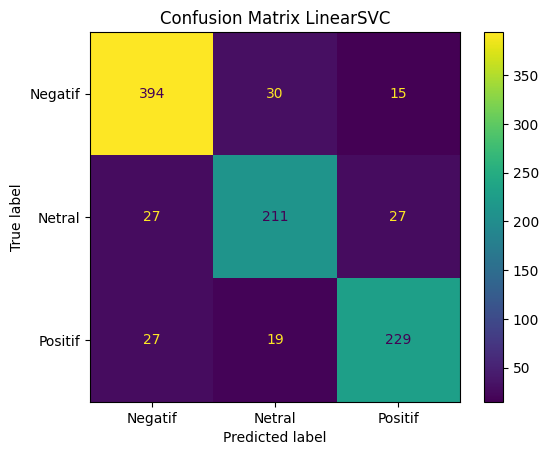

In [82]:
disp_svc = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=["Negatif", "Netral", "Positif"]
)

disp_svc.plot()
plt.title("Confusion Matrix LinearSVC")
plt.show()

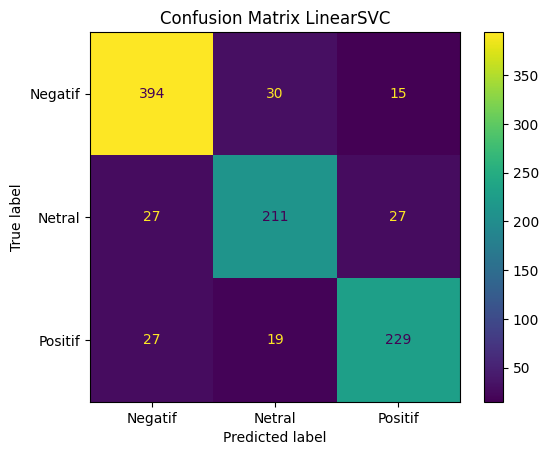

Gambar Confusion Matrix LinearSVC berhasil disimpan ke Google Drive.


In [83]:
disp_svc = ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=["Negatif", "Netral", "Positif"]
)

disp_svc.plot()
plt.title("Confusion Matrix LinearSVC")

plt.savefig(
    f"{folder_path}/confusion_matrix_linearsvc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gambar Confusion Matrix LinearSVC berhasil disimpan ke Google Drive.")

In [84]:
akurasi_nb = accuracy_score(y_test, y_pred_naivebayes)
precision_nb = precision_score(
    y_test, y_pred_naivebayes, average="weighted"
)
recall_nb = recall_score(
    y_test, y_pred_naivebayes, average="weighted"
)
f1_nb = f1_score(
    y_test, y_pred_naivebayes, average="weighted"
)

print("Evaluasi Multinomial Naive Bayes")
print(f"Accuracy  : {akurasi_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"F1-Score  : {f1_nb:.4f}")

Evaluasi Multinomial Naive Bayes
Accuracy  : 0.6619
Precision : 0.7334
Recall    : 0.6619
F1-Score  : 0.6220


In [85]:
print(classification_report(
    y_test,
    y_pred_naivebayes,
    labels=["positif", "netral", "negatif"]
))

              precision    recall  f1-score   support

     positif       0.79      0.61      0.69       275
      netral       0.90      0.23      0.36       265
     negatif       0.60      0.96      0.74       439

    accuracy                           0.66       979
   macro avg       0.76      0.60      0.60       979
weighted avg       0.73      0.66      0.62       979



In [86]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Membuat confusion matrix Multinomial Naive Bayes
cm_nb = confusion_matrix(
    y_test,
    y_pred_naivebayes,
    labels=["negatif", "netral", "positif"]
)

# Membuat tabel confusion matrix
tabel_cm_nb = pd.DataFrame(
    cm_nb,
    index=["Negatif", "Netral", "Positif"],
    columns=["Negatif", "Netral", "Positif"]
)

tabel_cm_nb.index.name = "Aktual / Prediksi"

tabel_cm_nb

,Negatif,Netral,Positif
Aktual / Prediksi,,,
Negatif,421,4,14
Netral,174,60,31
Positif,105,3,167


In [87]:
tabel_cm_nb.to_csv(
    f"{folder_path}/confusion_matrix_naivebayes.csv",
    index=True
)

print("Confusion matrix Multinomial Naive Bayes berhasil disimpan.")

Confusion matrix Multinomial Naive Bayes berhasil disimpan.


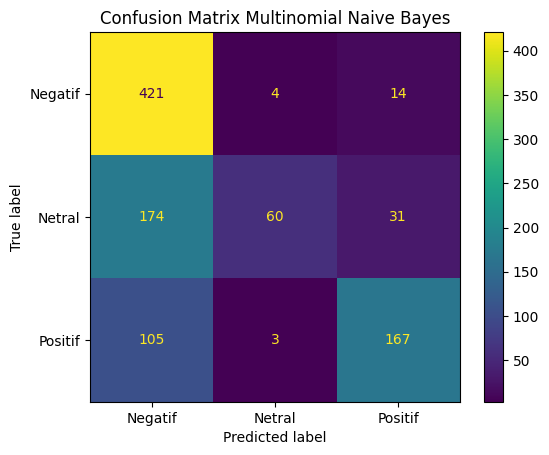

In [88]:
disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Negatif", "Netral", "Positif"]
)

disp_nb.plot()
plt.title("Confusion Matrix Multinomial Naive Bayes")
plt.show()

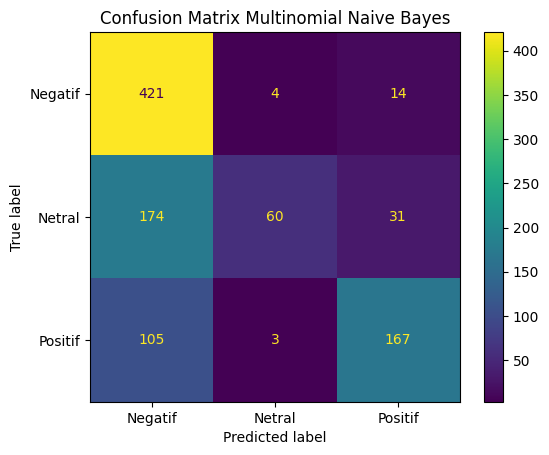

Gambar Confusion Matrix Multinomial Naive Bayes berhasil disimpan ke Google Drive.


In [89]:
disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Negatif", "Netral", "Positif"]
)

disp_nb.plot()
plt.title("Confusion Matrix Multinomial Naive Bayes")

plt.savefig(
    f"{folder_path}/confusion_matrix_naivebayes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gambar Confusion Matrix Multinomial Naive Bayes berhasil disimpan ke Google Drive.")

# 8.Perbandingan Performa Model

In [90]:
hasil_perbandingan = pd.DataFrame({

    "Model": [
        "LinearSVC",
        "Multinomial Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_linearsvc),
        accuracy_score(y_test, y_pred_naivebayes)
    ],

    "Precision": [
        precision_score(
            y_test, y_pred_linearsvc, average="weighted"
        ),
        precision_score(
            y_test, y_pred_naivebayes, average="weighted"
        )
    ],

    "Recall": [
        recall_score(
            y_test, y_pred_linearsvc, average="weighted"
        ),
        recall_score(
            y_test, y_pred_naivebayes, average="weighted"
        )
    ],

    "F1-Score": [
        f1_score(
            y_test, y_pred_linearsvc, average="weighted"
        ),
        f1_score(
            y_test, y_pred_naivebayes, average="weighted"
        )
    ]
})

kolom_metrik = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

hasil_perbandingan[kolom_metrik] = (
    hasil_perbandingan[kolom_metrik] * 100
).round(2)

for kolom in kolom_metrik:
    hasil_perbandingan[kolom] = (
        hasil_perbandingan[kolom].astype(str) + "%"
    )

hasil_perbandingan

,Model,Accuracy,Precision,Recall,F1-Score
0,LinearSVC,85.19%,85.14%,85.19%,85.16%
1,Multinomial Naive Bayes,66.19%,73.34%,66.19%,62.2%


In [91]:
hasil_perbandingan.to_csv(
    f"{folder_path}/perbandingan_performa_model.csv",
    index=False
)

print("Tabel perbandingan performa model berhasil disimpan.")

Tabel perbandingan performa model berhasil disimpan.


In [94]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [95]:
# Membuat dan melatih model LinearSVC
model_svc = LinearSVC(random_state=42)

model_svc.fit(X_train, y_train)

# Prediksi data testing
y_pred_svc = model_svc.predict(X_test)

print("Prediksi LinearSVC berhasil.")

Prediksi LinearSVC berhasil.


In [96]:
# Membuat dan melatih model Multinomial Naive Bayes
model_nb = MultinomialNB()

model_nb.fit(X_train, y_train)

# Prediksi data testing
y_pred_nb = model_nb.predict(X_test)

print("Prediksi Multinomial Naive Bayes berhasil.")

Prediksi Multinomial Naive Bayes berhasil.


In [97]:
print("Jumlah prediksi SVM :", len(y_pred_svc))
print("Jumlah prediksi NB  :", len(y_pred_nb))
print("Jumlah data testing :", len(y_test))

Jumlah prediksi SVM : 979
Jumlah prediksi NB  : 979
Jumlah data testing : 979


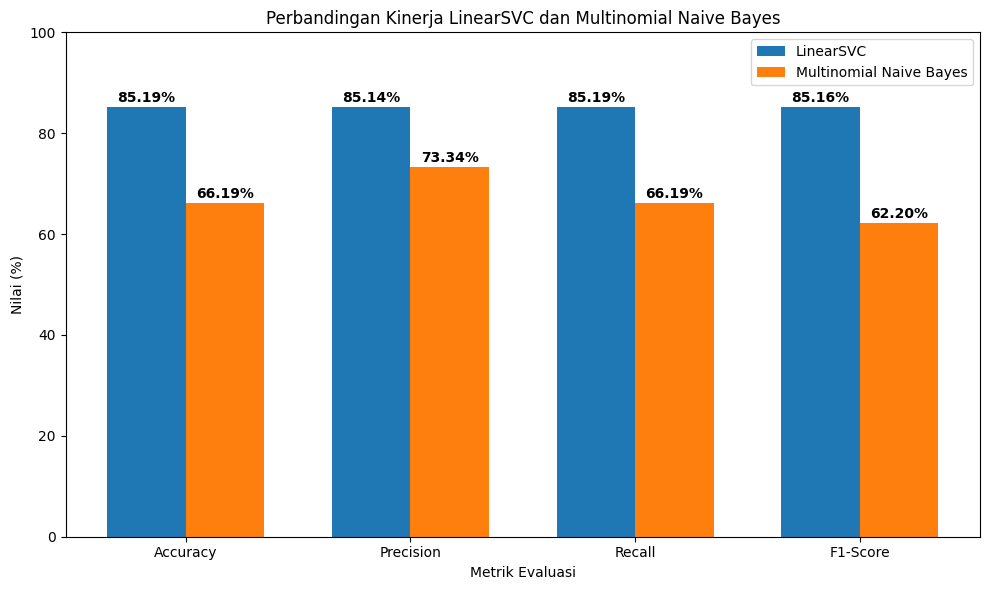

Grafik perbandingan kinerja model berhasil disimpan.


In [98]:
import matplotlib.pyplot as plt
import numpy as np

# Menghitung metrik LinearSVC
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(
    y_test, y_pred_svc, average="weighted"
)
recall_svc = recall_score(
    y_test, y_pred_svc, average="weighted"
)
f1_svc = f1_score(
    y_test, y_pred_svc, average="weighted"
)

# Menghitung metrik Multinomial Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(
    y_test, y_pred_nb, average="weighted"
)
recall_nb = recall_score(
    y_test, y_pred_nb, average="weighted"
)
f1_nb = f1_score(
    y_test, y_pred_nb, average="weighted"
)

# Nama metrik
metrik = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

svc = [
    accuracy_svc,
    precision_svc,
    recall_svc,
    f1_svc
]

nb = [
    accuracy_nb,
    precision_nb,
    recall_nb,
    f1_nb
]

# Posisi batang
x = np.arange(len(metrik))
lebar = 0.35

plt.figure(figsize=(10, 6))

bars_svc = plt.bar(
    x - lebar / 2,
    np.array(svc) * 100,
    lebar,
    label="LinearSVC"
)

bars_nb = plt.bar(
    x + lebar / 2,
    np.array(nb) * 100,
    lebar,
    label="Multinomial Naive Bayes"
)

# Judul dan label
plt.title(
    "Perbandingan Kinerja LinearSVC dan Multinomial Naive Bayes"
)
plt.ylabel("Nilai (%)")
plt.xlabel("Metrik Evaluasi")

plt.xticks(x, metrik)
plt.ylim(0, 100)

# Menampilkan nilai di atas batang
for bars in [bars_svc, bars_nb]:
    for bar in bars:
        nilai = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            nilai + 1,
            f"{nilai:.2f}%",
            ha="center",
            fontweight="bold"
        )

plt.legend()
plt.tight_layout()

# Simpan ke Google Drive
plt.savefig(
    f"{folder_path}/perbandingan_kinerja_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Grafik perbandingan kinerja model berhasil disimpan.")

In [99]:
distribusi_label = df["label"].value_counts()

print("Distribusi Label Sentimen:")
print(distribusi_label)

Distribusi Label Sentimen:
label
negatif    2193
positif    1374
netral     1324
Name: count, dtype: int64


In [100]:
persentase_label = (
    df["label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Persentase Label Sentimen:")
print(persentase_label)

Persentase Label Sentimen:
label
negatif    44.84
positif    28.09
netral     27.07
Name: proportion, dtype: float64


In [101]:
tabel_distribusi = pd.DataFrame({
    "Sentimen": distribusi_label.index,
    "Jumlah": distribusi_label.values,
    "Persentase (%)": persentase_label.values
})

tabel_distribusi

,Sentimen,Jumlah,Persentase (%)
0,negatif,2193,44.84
1,positif,1374,28.09
2,netral,1324,27.07


In [102]:
tabel_distribusi.to_csv(
    f"{folder_path}/distribusi_label_sentimen.csv",
    index=False
)

print("Distribusi label berhasil disimpan.")

Distribusi label berhasil disimpan.


In [103]:
tabel_distribusi

,Sentimen,Jumlah,Persentase (%)
0,negatif,2193,44.84
1,positif,1374,28.09
2,netral,1324,27.07
